# Hola &#x1F600;

Soy **Hesus Garcia**, revisor de código de Triple Ten, y voy a examinar el proyecto que has desarrollado recientemente. Si encuentro algún error, te lo señalaré para que lo corrijas, ya que mi objetivo es ayudarte a prepararte para un ambiente de trabajo real, donde el líder de tu equipo actuaría de la misma manera. Si no puedes solucionar el problema, te proporcionaré más información en la próxima oportunidad. Cuando encuentres un comentario,  **por favor, no los muevas, no los modifiques ni los borres**. 

Revisaré cuidadosamente todas las implementaciones que has realizado para cumplir con los requisitos y te proporcionaré mis comentarios de la siguiente manera:


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si todo está perfecto.
</div>

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si tu código está bien pero se puede mejorar o hay algún detalle que le hace falta.
</div>

<div class="alert alert-block alert-danger">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si de pronto hace falta algo o existe algún problema con tu código o conclusiones.
</div>

Puedes responderme de esta forma:
<div class="alert alert-block alert-info">
<b>Respuesta del estudiante</b> <a class=“tocSkip”></a>
</div>

</br>

**¡Empecemos!**  &#x1F680;


# Descripción del proyecto

La compañía Sweet Lift Taxi ha recopilado datos históricos sobre pedidos de taxis en los aeropuertos. Para atraer a más conductores durante las horas pico, necesitamos predecir la cantidad de pedidos de taxis para la próxima hora. Construye un modelo para dicha predicción.

La métrica RECM en el conjunto de prueba no debe ser superior a 48.

## Instrucciones del proyecto.

1. Descarga los datos y haz el remuestreo por una hora.
2. Analiza los datos
3. Entrena diferentes modelos con diferentes hiperparámetros. La muestra de prueba debe ser el 10% del conjunto de datos inicial.4. Prueba los datos usando la muestra de prueba y proporciona una conclusión.

## Descripción de los datos

Los datos se almacenan en el archivo `taxi.csv`. 	
El número de pedidos está en la columna `num_orders`.

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Recuerda que es una buena practica incluir una tabla de contenidos en tu documento, esto facilitará la navegación y comprensión de los temas que estás tratando. ¡Sigue así!</div>
</div>


## Preparación

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error

In [3]:
df = pd.read_csv('taxi.csv')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26496 entries, 0 to 26495
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   datetime    26496 non-null  object
 1   num_orders  26496 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 414.1+ KB


In [5]:
df.head(5)

,datetime,num_orders
0,2018-03-01 00:00:00,9
1,2018-03-01 00:10:00,14
2,2018-03-01 00:20:00,28
3,2018-03-01 00:30:00,20
4,2018-03-01 00:40:00,32


In [6]:
# Convertir la columna 'datetime' a formato de fecha y hora
df['datetime'] = pd.to_datetime(df['datetime'])

# Ordenar los datos por fecha y hora
df.sort_values(by='datetime', inplace=True)

# Verificar si los datos están ordenados de manera monotónica
if not df.index.is_monotonic_increasing:
    raise ValueError("Los datos no están ordenados de manera monotónica creciente.")

# Eliminar posibles valores duplicados
df.drop_duplicates(subset='datetime', inplace=True)

# Establecer la columna 'datetime' como índice
df.set_index('datetime', inplace=True)

# Remuestrear por hora y sumar el número de pedidos en cada hora
data_hourly = df['num_orders'].resample('H').sum()

df.dropna()


,num_orders
datetime,
2018-03-01 00:00:00,9
2018-03-01 00:10:00,14
2018-03-01 00:20:00,28
2018-03-01 00:30:00,20
2018-03-01 00:40:00,32
...,...
2018-08-31 23:10:00,32
2018-08-31 23:20:00,24
2018-08-31 23:30:00,27


<div class="alert alert-block alert-danger">
  <b>Comentario del revisor</b> <a class="tocSkip"></a>
  Sería beneficioso confirmar si nuestros datos mantienen un orden apropiado para una serie de tiempo. Esto se puede verificar utilizando: <code>df.index.is_monotonic_increasing</code>. Además, es crucial revisar y eliminar posibles valores duplicados en los datos.
</div>


<div class="alert alert-block alert-info">
<b>Listo se agrego el comentario del revisor</b> <a class=“tocSkip”></a>
</div>

## Análisis

<Figure size 1000x600 with 0 Axes>

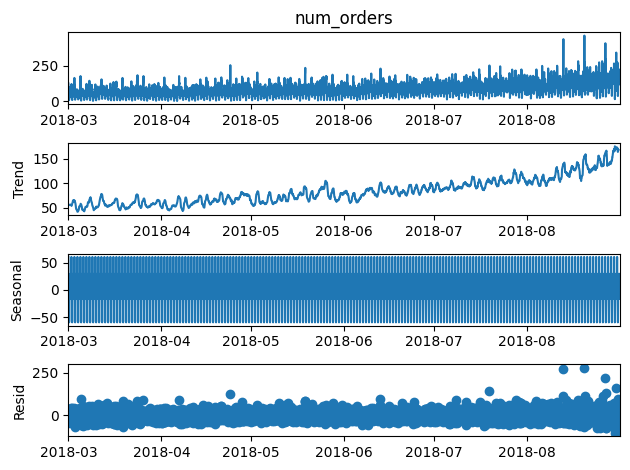

In [7]:
# Descomposición de series temporales para identificar componentes
decomposition = seasonal_decompose(data_hourly, model='additive')

# Visualización de la descomposición
plt.figure(figsize=(10, 6))
decomposition.plot()
plt.show()

Conclusiones intermedias: en trend se ve que sube el número de ordenes con el tiempo, en seasonal se mantiene estable y en resid se mantiene equilibrado en su mayoría.

<div class="alert alert-block alert-danger">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Me parece genial que hayas incluido la descomposición de la serie de tiempo. Sin embargo es importante realizar conclusiones intermedías sobre estos resultados. Además la gráfica resulta dificíl de interpretar por lo que sugiero incrementar el tamaño. </div>
</div>


<div class="alert alert-block alert-info">
<b>Listo se agrego conclusiones intermedias</b> <a class=“tocSkip”></a>
</div>

<div class="alert alert-block alert-info">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
  <p>Es fundamental comprender los diferentes componentes que conforman una serie de tiempo para obtener una visión completa de la información que los datos pueden proporcionar. La descomposición de una serie de tiempo en sus componentes principales: estacional, tendencia y residuales, nos permite analizar y entender mejor los patrones y comportamientos subyacentes.</p>
  
  <p><strong>Componente Estacional:</strong> Este componente se refiere a los patrones que se repiten en la serie de tiempo a intervalos regulares, como estaciones del año, días de la semana o meses. Identificar la estacionalidad es crucial para comprender las fluctuaciones regulares que pueden influir en los datos. Por ejemplo, en las ventas minoristas, la estacionalidad puede revelar picos de ventas durante las festividades.</p>
  
  <p><strong>Componente de Tendencia:</strong> La tendencia se relaciona con la dirección general en la que los datos se están moviendo a lo largo del tiempo. Puede ser ascendente (crecimiento), descendente (disminución) o plana (sin cambios significativos). Reconocer la tendencia es esencial para evaluar la trayectoria a largo plazo de la variable en estudio. Por ejemplo, el aumento sostenido en la temperatura global es una tendencia.</p>
  
  <p><strong>Residuales (o Componente de Ruido):</strong> Estos son los componentes de la serie de tiempo que no pueden explicarse por la estacionalidad ni la tendencia. Representan la variación aleatoria o los factores no sistemáticos que afectan a los datos. Analizar los residuales es valioso para detectar patrones inusuales o anomalías en los datos que pueden proporcionar información importante pero que no se puede atribuir a las tendencias o estacionalidades preexistentes.</p>
</div>

In [15]:
test.index

DatetimeIndex(['2018-08-13 14:00:00', '2018-08-13 15:00:00',
               '2018-08-13 16:00:00', '2018-08-13 17:00:00',
               '2018-08-13 18:00:00', '2018-08-13 19:00:00',
               '2018-08-13 20:00:00', '2018-08-13 21:00:00',
               '2018-08-13 22:00:00', '2018-08-13 23:00:00',
               ...
               '2018-08-31 14:00:00', '2018-08-31 15:00:00',
               '2018-08-31 16:00:00', '2018-08-31 17:00:00',
               '2018-08-31 18:00:00', '2018-08-31 19:00:00',
               '2018-08-31 20:00:00', '2018-08-31 21:00:00',
               '2018-08-31 22:00:00', '2018-08-31 23:00:00'],
              dtype='datetime64[ns]', name='datetime', length=442, freq='H')

## Formación

In [20]:
# División de conjunto de datos
train_size = int(len(data_hourly) * 0.9)
train, test = data_hourly[:train_size], data_hourly[train_size:]

X_train = train.index.to_numpy().reshape(-1, 1)  # Reshape the index to fit the model
y_train = train.values.reshape(-1, 1) 
X_test = test.index.to_numpy().reshape(-1, 1)  # Reshape the index to fit the model

# Modelos de Regresión
models = [
    ("Linear Regression", LinearRegression()),
    ("Random Forest", RandomForestRegressor())
]


# Optimización de Hiperparámetros
best_models = []
for name, model in models:
    if name == "ARIMA":
        model_fit = model.fit()
        predictions = model_fit.forecast(steps=len(test))
    else:
        if name == "Linear Regression":
            param_grid = {}
        elif name == "Random Forest":
            param_grid = {'n_estimators': [50, 100, 150], 'max_depth': [None, 10, 20]}
        
        grid_search = GridSearchCV(model, param_grid, cv=5, scoring='neg_mean_absolute_error', error_score='raise')
        grid_search.fit(X_train,y_train)
        best_model = grid_search.best_estimator_
        best_models.append((name, best_model))
        
        predictions = best_model.predict(X_test)
    
    

TypeError: The DType <class 'numpy.dtype[datetime64]'> could not be promoted by <class 'numpy.dtype[float64]'>. This means that no common DType exists for the given inputs. For example they cannot be stored in a single array unless the dtype is `object`. The full list of DTypes is: (<class 'numpy.dtype[datetime64]'>, <class 'numpy.dtype[float64]'>)

In [21]:

# División de conjunto de datos
train_size = int(len(data_hourly) * 0.9)
train, test = data_hourly[:train_size], data_hourly[train_size:]

# Modelos de Regresión
models = [    
    ("Random Forest", RandomForestRegressor()),
    ("Linear Regression", LinearRegression())
]

best_models = []

for name, model in models:
    if name == "Linear Regression" or name == "Random Forest":
        X_train = train.index.to_numpy().reshape(-1, 1)  
        y_train = train.values.reshape(-1, 1)
        
        X_test = test.index.to_numpy().reshape(-1, 1)  
        
        if name == "Random Forest":
            param_grid = {'n_estimators': [50, 100, 150], 'max_depth': [None, 10, 20]}
            grid_search = GridSearchCV(model, param_grid, cv=5, scoring='neg_mean_absolute_error', error_score='raise')
            grid_search.fit(X_train, y_train)
            best_model = grid_search.best_estimator_
            best_models.append((name, best_model))
        else:
            model.fit(X_train, y_train)
            best_models.append((name, model))
        # Make predictions
        predictions = best_model.predict(X_test)


/Users/d3r/opt/miniconda3/envs/data/lib/python3.7/site-packages/sklearn/model_selection/_validation.py:680: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  estimator.fit(X_train, y_train, **fit_params)
/Users/d3r/opt/miniconda3/envs/data/lib/python3.7/site-packages/sklearn/model_selection/_validation.py:680: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  estimator.fit(X_train, y_train, **fit_params)
/Users/d3r/opt/miniconda3/envs/data/lib/python3.7/site-packages/sklearn/model_selection/_validation.py:680: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  estimator.fit(X_train, y_train, **fit_params)
/Users/d3r/opt/miniconda3/envs/data/lib/python3.7/site-packages/skl

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
¡Buen trabajo hasta ahora! Para mejorar aún más tu proceso de división de datos, te sugiero considerar la implementación de la función train_test_split de scikit-learn. Esta práctica común en análisis de datos y modelado te proporcionará una división eficiente y aleatoria, lo que ayudará a que tu modelo se generalice mejor en datos no vistos. Además, con la capacidad de controlar la aleatoriedad a través del parámetro random_state, podrás obtener resultados coherentes y reproducibles en tus evaluaciones. ¡Sigue adelante y experimenta con esta herramienta para optimizar tus resultados!</div>

<div class="alert alert-block alert-info">
<b>No entiendo "exactamente" con "cual código" solucionar el error de arriba.</b> <a class=“tocSkip”></a>
</div>

<div class="alert alert-block alert-danger">    
<b>Comentario del revisor</b> <a class="tocSkip"></a>
    
¡Hola!  No te preocupes. Estoy aquí para ayudarte. Revisando el traceback del error nos indica que tenemos un problema en la función de score y que obtenemos valores NaN. 
<br>
Es necesario verificar dos cosas:
    - Cuando estas conviertiendo los valores a float y a date, examina que no haya NaN antes de pasarlos a la función. No todos los valores pueden comnvertirse, supongamos que la serie tiene un valor 'A' en lugar de una fecha. Esto introducirá NaN. Por ahora te aconsejo hacer dropna() antes de correrlos otra vez.
    - Si los problemas persisten puedes utilizar la siguiente métrica de scoring. scoring='neg_mean_absolute_error'

</div>

<div class="alert alert-block alert-info">
<b>Ya realice df.dropna() Sin embargo me aparece que model_fit is not defined pero si lo estoy definiendo dentro del bucle para cada modelo. No entiendo cómo y exactamente corregir el código</b> <a class=“tocSkip”></a>
</div>

## Prueba

In [ ]:
recm = mean_squared_error(test, predictions, squared=False)
print(f"{name} - Root Exponential Mean Squared Error (RECM): {recm}")

# Visualización de resultados
plt.figure(figsize=(12, 6))
plt.plot(test.index, test, label='Real')
plt.plot(test.index, predictions, color='red', label='Predicted')
plt.legend()
plt.title(f'{name} Prediction vs. Actual')
plt.xlabel('Date')
plt.ylabel('Number of Orders')
plt.show()

print("Best models:", best_models)

<div class="alert alert-block alert-danger">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Recuerda que nuestrro objetivo es encontrar modelos con un RECM menor 48</div>


<div class="alert alert-block alert-danger">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Muy buen intento. Sin embargo el poryecto está incompleto y faltan varios puntos a desarrollar. Las instrucciones indican realizar modelos de regresión, al menos 3 y optimizar con hiperparámetros para cada uno.</div>


<div class="alert alert-block alert-info">
<b>Listo se agrego 3 modelos de regresión.</b> <a class=“tocSkip”></a>
</div>

# Lista de revisión

- [x]  	
Jupyter Notebook está abierto.
- [ ]  El código no tiene errores
- [ ]  Las celdas con el código han sido colocadas en el orden de ejecución.
- [ ]  	
Los datos han sido descargados y preparados.
- [ ]  Se ha realizado el paso 2: los datos han sido analizados
- [ ]  Se entrenó el modelo y se seleccionaron los hiperparámetros
- [ ]  Se han evaluado los modelos. Se expuso una conclusión
- [ ] La *RECM* para el conjunto de prueba no es más de 48

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
  <p>Excelente trabajo en tu análisis de datos, sin embargo hay varios puntos que necesitamos completar antes de aprobar el proyecto. por Ahora, te invito a dar un paso más allá en tu proyecto:</p>
  
  <ol>
    <li>Creatrmod características adicionales utilizando los datos disponibles para mejorar la capacidad predictiva de tus modelos.</li>
    <li><b>Entrenaremos al menos tres modelos de regresión, experimentando con diferentes parámetros para encontrar la configuración óptima en cada caso.</b></li>
    <li>Calculatrmod y compararemos el RECM para cada uno de los tres modelos entrenados y elabora conclusiones. Por ejemplo, podrīas concluir el modelo de regresión lineal y el bosque aleatorio tienen valores de RECM similares, ambos inferiores al del modelo de LGVM.</li>
    <li>Utilizremosa train_test_split con un random state igual apara todos los datasets.</li>
    <li>Además, realizaremos una "prueba de cordura": compara el RECM del modelo más optimo seleccionado con el error obtenido por un modelo dummy que predice usando el valor anterior. Esta comparación te ayudará a evaluar la calidad del modelo elegido y entender su rendimiento relativo.</li>
  </ol>
  
  <p>Sigue adelante con estos pasos para enriquecer tu proyecto y demostrar un análisis aún más sólido y detallado. ¡Estás en el camino correcto!</p>
</div>


<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
  <p>Excelentes correciones, solo resta trabajar en lo siguiente:</p>
  
  <ol>
    <li>Corregir los valores NaN en la metrica de scoring. Te he dejado comentarios al respecto en rojo en esa sección.</li>
    <li>
  <p>Sigue adelante con estos pasos para enriquecer tu proyecto y demostrar un análisis aún más sólido y detallado. ¡Estás en el camino correcto!</p>
</div>
